In [ ]:
import math
import os
import importlib
import numpy as np
import json
import scipy as sp
from scipy.sparse import csc_array

from pymrm import non_uniform_grid, construct_coefficient_matrix, construct_grad, construct_div, construct_convflux_upwind, interp_cntr_to_stagg_tvd, minmod, update_csc_array_indices, interp_cntr_to_stagg, interp_stagg_to_cntr, compute_boundary_values, construct_interface_matrices, NumJac, newton
from gas_mixture_correlations import GasMixtureCorrelations
from ammonia_synthesis_kinetics import AmmoniaSynthesisKinetics
import defaults  # Import the defaults module

class MembraneReactor:
    def __init__(self, config_file=None, **kwargs):
        """Initialize the reactor with defaults from defaults.py, optional JSON, and keyword arguments."""

        # Step 1: Load defaults from the Python module
        importlib.reload(defaults)
        param_dict = defaults.DEFAULTS.copy()  # Copy to avoid modifying the original

        # Evaluate any lambda functions in defaults
        for key, value in param_dict.items():
            if callable(value):  # If it's a function, evaluate it with kwargs
                param_dict[key] = value(kwargs.get("temperature", param_dict["temperature"]))

        # Step 2: Load user-supplied settings from a JSON file (if provided)
        if config_file and os.path.exists(config_file):
            with open(config_file, "r") as f:
                user_config = json.load(f)
            param_dict.update(user_config)  # Override defaults with user values

        # Step 3: Override with explicitly provided kwargs
        param_dict.update(kwargs)

        # Assign attributes
        for key, value in param_dict.items():
            setattr(self, key, value)

        self.init_derived_parameters()
        self.init_fields()
        _, T_R = self.split_P_and_R(self.T)
        _, p_R = self.split_P_and_R(self.p)

        self.kinetics = AmmoniaSynthesisKinetics(self.species, T=self.T, p=self.p, rho_b=self.rho_b, rho_c=self.rho_c)
        self.init_jac()

    def init_derived_parameters(self):
        self.num_c = len(self.species)
        self.rho_b = self.rho_c*self.Dcat*(1-self.eps) #[Kgcat/m3R] bed density    
        
        self.correlation = GasMixtureCorrelations(self.species, self.database)    
        
        self.num_r_P = np.round(self.r_max_P / self.r_max *self.num_r).astype('int') + 3
        self.num_r_R = self.num_r - self.num_r_P
        self.make_spatial_discretization()

        # membrane permeabilities
        perm_dict= {'NH3': self.Perm_NH3, 'H2': self.Perm_NH3 / self.Sel_am_hy, 'N2': self.Perm_NH3 / self.Sel_am_ni}
        perm = np.zeros((1, 1, self.num_c))
        for i, species in enumerate(self.species):
            perm[0, 0, i] = perm_dict[species]
        perm = np.broadcast_to(perm, (self.num_z, 1, self.num_c))
        fltr = (self.z_c <= self.Lsealing) 
        if (any(fltr)):
            perm = perm.copy()
            perm[fltr,:,:] = 0
        self.Perm = perm
        
        # Gas Composition at Inlet    
        self.y0 = np.array([
            (1 - self.yNH3_init)* self.q / (1 + self.q), 
            (1 - self.yNH3_init) / (1 + self.q), 
            self.yNH3_init
        ])
        self.y0_P = np.array([
            self.q / (1 + self.q), 
            1.0 / (1 + self.q), 
            0.0
        ])

        # Bed and Catalyst Density
        self.rho_b = self.rho_c * self.Dcat * (1 - self.eps)  # Bed density [kg/m³ reactor]

        # reactor geometry
        #self.Pm = np.pi * self.r_min  # Membrane circumference [m]
        #self.Vtot = self.Ab * self.L  # Total reactor volume (excluding permeate) [m³]

        Mw = self.correlation.Mw  # Molar weights [g/mol]
        index_NH3 = self.species.index('NH3')
        
        # Reactor Flow Conditions
        rho_g = self.correlation.density(self.y0, self.T_in, self.p_out)  # Gas density [kg/m³]
        self.Fm_R_in = self.Fmass_NH3_target / self.guess_conv / Mw[1] * self.y0 / self.y0[1] / 3600  # [mol/s]
        self.Fv_R_in = np.sum(self.Fm_R_in * Mw) / rho_g  # Volumetric flow rate [m³/s]
        Ab = np.pi * (self.r_max**2 - self.r_min**2)  # Reactor cross-section [m²]
        self.u0 = self.Fv_R_in / Ab  # Superficial velocity [m/s]
        
        self.p_in = self.p_out + 1e2;
        self.p_P_in = self.p_P_out + 1e2;        
        
        rho_g_P = self.correlation.density(self.y0_P, self.T_P_in, self.p_P_out)  # Gas density permeate side [kg/m³]
        self.Fm_R_in = self.SW * np.sum(self.Fm_R_in) * self.y0_P  # [mol/s]
        Ami = np.pi * self.r_max_P**2  # Membrane inner cross-section [m²]
        self.u0_P = np.sum(self.Fm_R_in * Mw) / rho_g_P/ Ami  # Volumetric flow rate [m³/s]
        
       
        viscosity = self.correlation.viscosity(self.y0, self.T_in)  # Gas viscosity [Pa s]
        D = self.correlation.diffusion(self.y0, self.T_in, self.p_out)  # Gas viscosity [Pa s]        
        # Reynolds and Schmidt Numbers
        self.Re = rho_g * self.u0 * 2 * self.r_max / viscosity
        self.Sc = viscosity / rho_g / np.mean(D)
        self.ReSc = self.Re * self.Sc
        self.rL = self.r_max / self.L
        self.Lr = self.L / self.r_max

    def make_spatial_discretization(self):
        # Time-Stepping
        #self.num_time_steps = int(np.round(self.L / self.u0 / self.dt * 5))
        # create grid
        # self.r_f = np.linspace(self.r_min, self.r_max, self.num_r+1)
        self.r_f = non_uniform_grid(self.r_min, self.r_max, self.num_r_R+1, (self.r_max - self.r_min)/np.maximum(self.num_r_R-10, 0.8*self.num_r_R), 1.2)
        self.r_c = 0.5 * (self.r_f[0:-1] + self.r_f[1:])
        # self.r_f_P = np.linspace(self.r_min_P, self.r_max_P, self.num_r_P+1)
        self.r_f_P = non_uniform_grid(self.r_min_P, self.r_max_P, self.num_r_P+1, (self.r_max_P - self.r_min_P)/np.maximum(self.num_r_P-10, 0.8*self.num_r_P), 1.0/1.2)
        self.r_c_P = 0.5 * (self.r_f_P[0:-1] + self.r_f_P[1:])
        # self.z_f = np.linspace(0, self.L, self.num_z+1)
        self.z_f = non_uniform_grid(0, self.L, self.num_z+1, self.L / np.maximum(self.num_z-10, 0.8*self.num_z), 1.2)
        self.z_c = 0.5 * (self.z_f[0:-1] + self.z_f[1:])

    def init_jac(self):
        """
        Initialize the Jacobian matrices for the system. 
        This includes setting up the accumulation, convection, and diffusion terms.
        """
        shape_c = (self.num_z, self.num_r, self.num_c)
        shape_c_R = (self.num_z, self.num_r_R, self.num_c)
        shape_c_P = (self.num_z, self.num_r_P, self.num_c)
        shape_p = (self.num_z, self.num_r)
        shape_p_R = (self.num_z, self.num_r_R)
        shape_p_P = (self.num_z, self.num_r_P)
       
        bc_dirichlet = {'a': 0, 'b':1 , 'd' : 1}
        bc_dirichlet_0 = {'a': 0, 'b':1 , 'd' : 0}
        bc_neumann = {'a': 1, 'b': 0, 'd': 0}
        
        jac_c_accum_P = construct_coefficient_matrix(1.0 / self.dt, shape_c_P)
        jac_c_accum_R = construct_coefficient_matrix(self.eps / self.dt, shape_c_R)
        self.div_c_P_ax  = construct_div(shape_c_P, self.z_f, nu=0, axis=0)
        self.div_c_P_rad = construct_div(shape_c_P, self.r_f_P, nu=self.nu, axis=1)
        self.div_c_R_ax  = construct_div(shape_c_R, self.z_f, nu=0, axis=0)
        self.div_c_R_rad = construct_div(shape_c_R, self.r_f, nu=self.nu, axis=1)
        self.grad_c_P_ax, self.grad_bc_c_P_ax   = construct_grad(shape_c_P, self.z_f, self.z_c, bc=(bc_dirichlet, bc_neumann), axis=0)
        self.grad_c_P_rad, _, self.grad_bc_c_P_rad = construct_grad(shape_c_P, self.r_f_P, self.r_c_P, bc=(bc_neumann, bc_dirichlet), axis=1, shapes_d = (None, (self.num_z, 1, self.num_c)))
        self.grad_c_R_ax, self.grad_bc_c_R_ax   = construct_grad(shape_c_R, self.z_f, self.z_c, bc=(bc_neumann, bc_dirichlet_0), axis=0)
        self.grad_c_R_rad, self.grad_bc_c_R_rad, _ = construct_grad(shape_c_R, self.r_f, self.r_c, bc=(bc_dirichlet, bc_neumann), axis=1, shapes_d = ((self.num_z, 1, self.num_c), None))
        
        self.div_p_P_ax  = construct_div(shape_p_P, self.z_f, nu=0, axis=0)
        self.div_p_P_rad = construct_div(shape_p_P, self.r_f_P, nu=self.nu, axis=1)
        self.div_p_R_ax  = construct_div(shape_p_R, self.z_f, nu=0, axis=0)
        self.div_p_R_rad = construct_div(shape_p_R, self.r_f, nu=self.nu, axis=1)
        self.grad_p_P_ax, self.grad_bc_p_P_ax_in, self.grad_bc_p_P_ax_out   = construct_grad(shape_p_P, self.z_f, self.z_c, bc=(bc_dirichlet, bc_dirichlet), axis=0, shapes_d = ((1,1),None))
        self.grad_bc_p_P_ax_out *= self.p_P_out
        self.grad_p_P_rad, _ = construct_grad(shape_p_P, self.r_f_P, self.r_c_P, bc=(bc_neumann, bc_neumann), axis=1)
        self.grad_p_R_ax, self.grad_bc_p_R_ax_in, self.grad_bc_p_R_ax_out = construct_grad(shape_p_R, self.z_f, self.z_c, bc=(bc_dirichlet, bc_dirichlet), axis=0, shapes_d = ((1,1),None))
        self.grad_bc_p_R_ax_out *= self.p_out
        self.grad_p_R_rad, _ = construct_grad(shape_p_R, self.r_f, self.r_c, bc=(bc_neumann, bc_neumann), axis=1)
        
        # shift retentate-side matrix indices to (later) build a monolithic spatial discretization
        offset = (0, self.num_r_P, 0)
        offset_p = (0, self.num_r_P)
        jac_c_accum_P = update_csc_array_indices(jac_c_accum_P, shape_c_P, shape_c)
        jac_c_accum_R = update_csc_array_indices(jac_c_accum_R, shape_c_R, shape_c, offset=offset)
        self.jac_c_accum = jac_c_accum_P + jac_c_accum_R
        self.div_c_R_ax    = update_csc_array_indices(self.div_c_R_ax, (shape_c_R,None), (shape_c,None), offset=(offset,None))
        self.div_c_R_rad   = update_csc_array_indices(self.div_c_R_rad, (shape_c_R,None), (shape_c,None), offset=(offset,None))
        self.div_c_P_ax    = update_csc_array_indices(self.div_c_P_ax, (shape_c_P,None), (shape_c,None))
        self.div_c_P_rad   = update_csc_array_indices(self.div_c_P_rad, (shape_c_P,None), (shape_c,None))
        self.grad_c_R_ax   = update_csc_array_indices(self.grad_c_R_ax, (None, shape_c_R), (None, shape_c), offset=(None, offset))
        self.grad_c_R_rad  = update_csc_array_indices(self.grad_c_R_rad, (None, shape_c_R), (None, shape_c), offset=(None, offset))
        self.grad_c_P_ax   = update_csc_array_indices(self.grad_c_P_ax, (None, shape_c_P), (None, shape_c))
        self.grad_c_P_rad  = update_csc_array_indices(self.grad_c_P_rad, (None, shape_c_P), (None, shape_c))

        self.div_p_R_ax    = update_csc_array_indices(self.div_p_R_ax, (shape_p_R,None), (shape_p,None), offset=(offset_p,None))
        self.div_p_R_rad   = update_csc_array_indices(self.div_p_R_rad, (shape_p_R,None), (shape_p,None), offset=(offset_p,None))
        self.div_p_P_ax    = update_csc_array_indices(self.div_p_P_ax, (shape_p_P,None), (shape_p,None))
        self.div_p_P_rad   = update_csc_array_indices(self.div_p_P_rad, (shape_p_P,None), (shape_p,None))
        self.grad_p_R_ax   = update_csc_array_indices(self.grad_p_R_ax, (None, shape_p_R), (None, shape_p), offset=(None, offset_p))
        self.grad_p_R_rad  = update_csc_array_indices(self.grad_p_R_rad, (None, shape_p_R), (None, shape_p), offset=(None, offset_p))
        self.grad_p_P_ax   = update_csc_array_indices(self.grad_p_P_ax, (None, shape_p_P), (None, shape_p))
        self.grad_p_P_rad  = update_csc_array_indices(self.grad_p_P_rad, (None, shape_p_P), (None, shape_p))

        self.numjac = NumJac(shape_c_R)
        self.numjac_p = NumJac(shape_p + (1,))
        values = np.ones(shape_c)
        num_rows = np.prod(shape_p)
        num_cols = np.prod(shape_c)
        row_indices = np.broadcast_to(np.arange(shape_c[0:1],dtype=int).rehape(shape_p+(1,)), shape_c)
        col_ptrs = np.arange(np.prod(shape_c)+1,dtype=int)
        self.sum_c = csc_array((values, row_indices, col_ptrs), shape=(num_rows, num_cols))

    def temp(self):
        self.idx_seal = len(self.z_c[self.z_c < self.Lsealing])

        # create matrices for pressure equation, retentate side
        shape_p = (self.num_z, self.num_r_R)
        self.bc_p = [None] * self.dim
        self.Grad_p = [None] * self.dim
        self.grad_p_bc = [None] * self.dim
        self.Vel_p = [None] * self.dim
        self.vel_p_bc = [None] * self.dim
        self.Div_p = [None] * self.dim

        self.bc_p[0] = ({'a':0, 'b':0, 'd':0},{'a':0, 'b':1, 'd':self.p_out})
        self.Grad_p[0], self.grad_p_bc[0] = construct_grad(shape_p, self.z_f, self.z_c, bc=self.bc_p[0], axis=0)
        self.Div_p[0] = construct_div(shape_p, self.z_f, nu=0, axis=0)
        self.bc_p[1] = ({'a':1, 'b':0, 'd':0},{'a':1, 'b':0, 'd':0})        
        self.Grad_p[1], self.grad_p_bc[1] = construct_grad(shape_p, self.r_f, self.r_c, bc=self.bc_p[1], axis=1)
        factor_dpdr = 1e2*self.r_max*self.r_max/self.viscosity
        self.Vel_p[1] = -factor_dpdr*self.Grad_p[1]
        self.vel_p_bc[1] = -factor_dpdr*self.grad_p_bc[0]
        self.Div_p[1] = construct_div(shape_p, self.r_f, nu=1, axis=1)
        
        # create matrices for pressure equation, permeate side
        shape_p_P = (self.num_z, self.num_r_P)
        self.bc_p_P = [None] * self.dim
        self.Grad_p_P = [None] * self.dim
        self.grad_p_bc_P = [None] * self.dim
        self.Vel_p_P = [None] * self.dim
        self.vel_p_bc_P = [None] * self.dim
        self.Div_p_P = [None] * self.dim
        
        self.bc_p_P[0] = ({'a':0, 'b':0, 'd':0},{'a':0, 'b':1, 'd':self.p_P_out})
        self.Grad_p_P[0], self.grad_p_bc_P[0] = construct_grad(shape_p_P, self.z_f, self.z_c, bc=self.bc_p_P[0], axis=0)
        self.Div_p_P[0] = construct_div(shape_p_P, self.z_f, nu=0, axis=0)
        
        self.bc_p_P[1] = ({'a':1, 'b':0, 'd':0},{'a':1, 'b':0, 'd':0})
        self.Grad_P[1], self.grad_p_bc_P[1] = construct_grad(shape_p_P, self.r_f_P, self.r_c_P, bc=self.bc_p_P[1], axis=1)
        factor_dpdr_P = 1e2*self.r_max_P*self.r_max_P/self.viscosity_P
        self.Vel_p_P[1] = -factor_dpdr_P*self.Grad_p_P[1]
        self.vel_p_bc_P[1] = -factor_dpdr_P*self.grad_p_bc_P[1]
        self.Div_p_P[1] = construct_div(shape_p_P, self.r_f_P, nu=1, axis=1)
        
        self.init_jac()
        self.set_velocity_field(self.u_ax, self.u_rad)

    def init_fields(self, c=None, p=None, T=None):
        """
        Initialize the concentration field.
        """
        shape_c = (self.num_z, self.num_r, self.num_c)
        shape_p = (self.num_z, self.num_r)
        shape_T = (self.num_z, self.num_r)
        
        self.T = np.empty(shape_T)
        
        if c is None:
            self.c = np.empty(shape_c)
            c_R = self.c[:, self.num_r_P:, :]
            c_R_0 = self.correlation.molar_density(self.y0, self.T_in, self.p_out)*self.y0
            c_R[:,:,:] = np.broadcast_to(c_R_0.reshape((1,1,-1)), c_R.shape)
            c_P = self.c[:, :self.num_r_P, :]
            c_P_0 = self.correlation.molar_density(self.y0_P, self.T_P_in, self.p_P_out)*self.y0_P
            c_P[:,:,:] = np.broadcast_to(c_P_0.reshape((1,1,-1)), c_P.shape)
        else:
            self.c = np.broadcast_to(np.array(c), shape_c).copy()

        if p is None:
            self.p = np.empty(shape_p)
            p_R = self.p[:, self.num_r_P:]
            p_R[:,:] = np.broadcast_to(np.array(self.p_out).reshape((1,1)), p_R.shape)
            p_P = self.p[:, :self.num_r_P]
            p_P[:,:] = np.broadcast_to(np.array(self.p_P_out).reshape((1,1)), p_P.shape)            
        else:
            self.p = np.broadcast_to(np.array(p), shape_p).copy()
            
        if T is None:
            T_R = self.T[:, self.num_r_P:]
            T_R[:,:] = np.broadcast_to(np.array(self.T_in).reshape((1,1)), T_R.shape)         
            T_P = self.T[:, :self.num_r_P]
            T_P[:,:] = np.broadcast_to(np.array(self.T_P_in).reshape((1,1)), T_P.shape)
        else:
            self.T = np.broadcast_to(np.array(T), shape_T).copy()
            
        self.u_P_ax = np.zeros((self.num_z+1, self.num_r_P))
        self.u_P_rad = np.zeros((self.num_z, self.num_r_P+1))
        self.u_R_ax = np.zeros((self.num_z+1, self.num_r_R))
        self.u_R_rad = np.zeros((self.num_z, self.num_r_R+1))
            
        return self.c, self.p, self.T
            
    def split_P_and_R(self, c):
        c = np.asarray(c)
        if c.ndim > 1 and c.shape[1] == self.num_r:
            c_P = c[:, 0:self.num_r_P, ...]
            c_R = c[:, self.num_r_P:self.num_r, ...]
        else:
            c_P = c
            c_R = c
        return c_P, c_R

    def construct_darcy_jacobian(self, c=None, T=None, p=None, v_ax_R=0):
        if c is None:
            c = self.c
        if T is None:
            T = self.T
        if p is None:
            p = self.p
        c_P, c_R = self.split_P_and_R(c)
        T_P, T_R = self.split_P_and_R(T)
        p_P, p_R = self.split_P_and_R(p)       
        v_ax_abs = np.abs(np.asarray(v_ax_R))
        if (v_ax_abs.ndim >0 and v_ax_abs.shape[0] == (self.num_z+1)):
            v_ax_abs = np.abs(interp_stagg_to_cntr(v_ax_R, self.z_f, self.z_c, axis=0))

        viscosity = self.correlation.viscosity(c_P, T_P)
        k_field =  0.25*(self.r_max_P**2-self.r_c_P**2).reshape((1, -1))/viscosity
        k_field_ax = interp_cntr_to_stagg(k_field, x_f=self.z_f, x_c=self.z_c, axis=0)
        k_matrix = construct_coefficient_matrix(k_field_ax, (self.num_z, self.num_r_P), axis=0)
        self.vel_matrix_P_ax = (-k_matrix) @ self.grad_p_P_ax
        jac_darcy = self.div_p_P_ax @ self.vel_matrix_P_ax
        self.vel_matrix_P_in = (-k_matrix) @ self.grad_bc_p_P_ax_in
        jac_darcy_bc_P_in = self.div_p_P_ax @ self.vel_matrix_P_in
        self.vel_bc_P_out = (-k_matrix) @ self.grad_bc_p_P_ax_out
        g_darcy_bc_out = self.div_p_P_ax @ self.vel_bc_P_out
        k_field   = 100*self.r_max_P**2/viscosity
        k_field_rad = interp_cntr_to_stagg(k_field, x_f=self.r_f_P, x_c=self.r_c_P, axis=1)
        k_matrix = construct_coefficient_matrix(k_field_rad, (self.num_z, self.num_r_P), axis=1) 
        self.vel_matrix_P_rad = (-k_matrix) @ self.grad_p_P_rad
        jac_darcy += self.div_p_P_rad @ self.vel_matrix_P_rad
        
        viscosity = self.correlation.viscosity(c_R, T_R)
        rho = self.correlation.density(c_R, T_R, p_R)
        beta = (150 * (1-self.eps)**2*viscosity / (self.eps**3 * self.dp**2) + 1.75 * rho *(1-self.eps) * np.abs(v_ax_abs) / (self.eps**3 * self.dp))
        beta_inv = 1.0/beta
        shape_p_R = (self.num_z, self.num_r_R)
        k_field_ax = interp_cntr_to_stagg(beta_inv, x_f=self.z_f, x_c=self.z_c, axis=0)
        k_matrix = construct_coefficient_matrix(k_field_ax, shape_p_R, axis=0)
        self.vel_matrix_R_ax = (-k_matrix) @ self.grad_p_R_ax
        jac_darcy += self.div_p_R_ax @ self.vel_matrix_R_ax
        self.vel_matrix_R_in = -(k_matrix @ self.grad_bc_p_R_ax_in)
        jac_darcy_bc_R_in = self.div_p_R_ax @ self.vel_matrix_R_in
        self.vel_bc_R_out = -(k_matrix @ self.grad_bc_p_R_ax_out)
        g_darcy_bc_out += self.div_p_R_ax @ self.vel_bc_R_out
        k_field_rad = interp_cntr_to_stagg(beta_inv, x_f=self.r_f, x_c=self.r_c, axis=1)
        k_matrix = construct_coefficient_matrix(k_field_rad, shape_p_R, axis=1)
        self.vel_matrix_R_rad = (-k_matrix) @ self.grad_p_R_rad
        jac_darcy += self.div_p_R_rad @ self.vel_matrix_R_rad
        return jac_darcy, jac_darcy_bc_P_in, jac_darcy_bc_R_in, g_darcy_bc_out
    
    def construct_g_diff(self, c = None, T = None, p = None, compute_jac = False):
        """
        Update the transport coefficients based on the current concentration field.

        Parameters:
        - c (numpy.ndarray): Current concentration field.
        """
        shape_c_R = (self.num_z, self.num_r_R, self.num_c)
        shape_c_P = (self.num_z, self.num_r_P, self.num_c)
        if c is None:
            c = self.c
        if T is None:
            T = self.T
        if p is None:
            p = self.p    
        c_P, c_R = self.split_P_and_R(c)
        T_P, T_R = self.split_P_and_R(T)
        p_P, p_R = self.split_P_and_R(p)
    
       # Retentate side
        g = np.empty(c.shape)
        g_vect = g.reshape((-1,1))
        if (compute_jac or not hasattr(self, jac_c_diff)):
            y_R = c_R/np.sum(c_R, axis=-1, keepdims=True)  # Mole fractions
            diff_field_R = self.correlation.diffusion(y_R, T_R, p_R)
            diff_field_R_ax = interp_cntr_to_stagg(diff_field_R, x_f=self.z_f, x_c=self.z_c, axis=0)
            diff_matrix_R_ax = construct_coefficient_matrix(diff_field_R_ax, shape_c_R, axis=0)
            diff_field_R_rad = interp_cntr_to_stagg(diff_field_R, x_f=self.r_f, x_c=self.r_c, axis=1)
            diff_matrix_R_rad = construct_coefficient_matrix(diff_field_R_rad, shape_c_R, axis=1)

            y_P = c_P/np.sum(c_P, axis=-1, keepdims=True)  # Mole fractions
            diff_field_P = self.correlation.diffusion(y_P, T_P, p_P)
            diff_field_P_ax = interp_cntr_to_stagg(diff_field_P, x_f=self.z_f, x_c=self.z_c, axis=0)
            diff_matrix_P_ax = construct_coefficient_matrix(diff_field_P_ax, shape_c_P, axis=0)
            diff_field_P_rad = interp_cntr_to_stagg(diff_field_P, x_f=self.r_f_P, x_c=self.r_c_P, axis=1)
            diff_matrix_P_rad = construct_coefficient_matrix(diff_field_P_rad, shape_c_P, axis=1)
            
            jac_c_diff = self.div_c_R_ax @ (-diff_matrix_R_ax) @ self.grad_c_R_ax + self.div_c_R_rad @ (-diff_matrix_R_rad) @ self.grad_c_R_rad + self.div_c_P_ax @ (-diff_matrix_P_ax) @ self.grad_c_P_ax + self.div_c_P_rad @ (-diff_matrix_P_rad) @ self.grad_c_P_rad 
            g_bc_c_diff = self.div_c_R_ax @ ((-diff_matrix_R_ax) @ self.grad_bc_c_R_ax) +self.div_c_P_ax @ ((-diff_matrix_P_ax) @ self.grad_bc_c_P_ax)
            jac_ic_c_diff_P = self.div_c_P_rad @ ((-diff_matrix_P_rad) @ self.grad_bc_c_P_rad)
            jac_ic_c_diff_R = self.div_c_R_rad @ ((-diff_matrix_R_rad) @ self.grad_bc_c_R_rad)
            #jac_c_diff = self.div_c_R_ax @ self.grad_c_R_ax + self.div_c_R_rad @ self.grad_c_R_rad + self.div_c_P_ax @ self.grad_c_P_ax + self.div_c_P_rad @ self.grad_c_P_rad 
            #jac_bc_c_diff = self.div_c_R_ax @ self.grad_bc_c_R_ax + self.div_c_R_rad @ self.grad_bc_c_R_rad +self.div_c_P_ax @ self.grad_bc_c_P_ax + self.div_c_P_rad @ self.grad_bc_c_P_rad
            if (T_P.ndim > 1):
                bc_neumann = {'a': 1, 'b': 0, 'd': 0}
                _, _ ,T_P_i, _ = compute_boundary_values(T_P, self.r_f_P, self.r_c, bc=(bc_neumann, bc_neumann), axis=1)
                T_R_i,_,_,_ = compute_boundary_values(T_R, self.r_f, self.r_c, bc=(bc_neumann, bc_neumann), axis=1)
                P_P_i = self.Rg*T_P_i[...,np.newaxis]*self.Perm
                P_R_i = self.Rg*T_R_i[...,np.newaxis]*self.Perm
            else:
                P_P_i = self.Rg*T_P*self.Perm
                P_R_i = self.Rg*T_R*self.Perm
            ic_1 = {'a':(diff_field_P_rad[:,-1,:],0), 'b':(P_P_i,-P_R_i)}
            factor_geom = (self.r_f[0]/self.r_f_P[-1])**self.nu
            ic_2 = {'a':(0,factor_geom*diff_field_R_rad[:,0,:]), 'b':(-P_P_i,P_R_i)}
            interf_mat_P, _, interf_mat_R, _ = construct_interface_matrices((shape_c_P, shape_c_R), (self.r_f_P, self.r_f), ic=(ic_1, ic_2), axis=1)
            jac_c_diff = jac_c_diff + jac_ic_c_diff_P @ interf_mat_P + jac_ic_c_diff_R @ interf_mat_R

        g_vect[...] = g_bc_c_diff + jac_c_diff @ c.reshape((-1,1))
        if (compute_jac):
            return g, jac_c_diff
        else:
            return g, None  
    
    def update_velocity_fields(self, p=None, p_P_in=None, p_R_in=None):
        if (p is not None):
            self.p[:] = p
        if (p_P_in is not None):
            self.p_P_in = p_P_in
        if (p_R_in is not None):
            self.p_R_in = p_R_in

        self.u_P_ax.reshape((-1,1))[:] = self.vel_matrix_P_in*self.p_P_in + self.vel_matrix_P_ax @ self.p.reshape((-1,1)) + self.vel_bc_P_out
        self.u_P_rad.reshape((-1,1))[:] = self.vel_matrix_P_rad @ self.p.reshape((-1,1))
        self.u_R_ax.reshape((-1,1))[:] = self.vel_matrix_R_in*self.p_R_in + self.vel_matrix_R_ax @ self.p.reshape((-1,1)) + self.vel_bc_R_out
        self.u_R_rad.reshape((-1,1))[:] = self.vel_matrix_R_rad @ self.p.reshape((-1,1))     

        return self.u_P_ax, self.u_P_rad, self.u_R_ax, self.u_R_rad
    
    def construct_g_conv(self, c=None, compute_jac = False):
        if c is None:
            c = self.c
        bc_neumann = {'a': 1, 'b': 0, 'd': 0}
        g = np.empty(c.shape)
        g_vect = g.ravel()
        
        c_P = c[:, 0:self.num_r_P, :]
        g_P = c[:, 0:self.num_r_P, :]
        u_P_ax = self.u_P_ax[...,np.newaxis]
        u_P_rad = self.u_P_rad[...,np.newaxis]
        c_P_in = self.correlation.molar_density(self.y0_P, self.T_P_in, self.p_P_in).reshape((1,1,-1))*self.y0_P
        bc_P_in = {'a': 0, 'b':1 , 'd' : c_P_in}
        c_P_ax,_ = interp_cntr_to_stagg_tvd(c_P, self.z_f, self.z_c, bc = (bc_P_in, bc_neumann), v = u_P_ax, tvd_limiter = minmod, axis=0)
        flux_P_ax = u_P_ax * c_P_ax
        g_vect[:] = self.div_c_P_ax @ flux_P_ax.ravel()
        c_P_rad,_ = interp_cntr_to_stagg_tvd(c_P, self.r_f_P, self.r_c_P, bc = (bc_neumann, bc_neumann), v = u_P_rad, tvd_limiter = minmod, axis=1)
        flux_P_rad = u_P_rad * c_P_rad
        g_vect[:] += self.div_c_P_rad @ flux_P_rad.ravel()
        
        c_R = c[:, self.num_r_P:, :]
        g_R = c[:, self.num_r_P:, :]
        g_R_vect = g_R.ravel()
        u_R_ax = self.u_R_ax[...,np.newaxis]
        u_R_rad = self.u_R_rad[...,np.newaxis]
        c_R_in = self.correlation.molar_density(self.y0, self.T_in, self.p_R_in).reshape((1,1,-1))*self.y0
        bc_R_in = {'a': 0, 'b':1 , 'd' : c_R_in}
        c_R_ax,_ = interp_cntr_to_stagg_tvd(c_R, self.z_f, self.z_c, bc = (bc_R_in, bc_neumann), v = u_R_ax, tvd_limiter = minmod, axis=0)
        flux_R_ax = u_R_ax * c_R_ax
        g_vect[:] += self.div_c_R_ax @ flux_R_ax.ravel()
        c_R_rad,_ = interp_cntr_to_stagg_tvd(c_R, self.r_f, self.r_c, bc = (bc_neumann, bc_neumann), v = u_R_rad, tvd_limiter = minmod, axis=1)
        flux_R_rad = u_R_rad * c_R_rad
        g_vect[:] += self.div_c_R_rad @ flux_R_rad.ravel()        

        if compute_jac:
            conv_matrix_P_ax, conv_bc_P_ax = construct_convflux_upwind(c_P.shape, self.z_f, self.z_c, bc = (bc_P_in, bc_neumann), v = u_P_ax, axis=0)
            jac_P = self.div_c_P_ax @ conv_matrix_P_ax
            conv_matrix_P_rad, conv_bc_P_rad = construct_convflux_upwind(c_P.shape, self.r_f_P, self.r_c_P, bc = (bc_neumann, bc_neumann), v = u_P_rad, axis=1)
            jac_P += self.div_c_P_rad @ conv_matrix_P_rad
            conv_matrix_R_ax, conv_bc_R_ax = construct_convflux_upwind(c_R.shape, self.z_f, self.z_c, bc = (bc_R_in, bc_neumann), v = u_R_ax, axis=0)
            jac_R = self.div_c_R_ax @ conv_matrix_R_ax
            conv_matrix_R_rad, conv_bc_R_rad = construct_convflux_upwind(c_R.shape, self.r_f, self.r_c, bc = (bc_neumann, bc_neumann), v= u_R_rad, axis=1)
            jac_R += self.div_c_R_rad @ conv_matrix_R_rad
            jac_P = update_csc_array_indices(jac_P, (None, c_P.shape), (None, c.shape))
            jac_R = update_csc_array_indices(jac_R, (None, c_R.shape), (None, c.shape), offset=(None, (0,self.num_r_P,0)))
            jac = jac_P + jac_R
            return g, jac
        else:
            return g, None
           
    def construct_g(self, c=None, c_old=None, compute_jac=False):
        """
        Construct the residual vector g and the Jacobian matrix for the system.

        Parameters:
        - c (numpy.ndarray): Current concentration field.
        - c_old (numpy.ndarray): Previous concentration field.

        Returns:
        - g (numpy.ndarray): Residual vector.
        - Jac (scipy.sparse.csc_matrix): Jacobian matrix.
        """
        if (c is None):
            c = self.c
        if (c_old is None):
            c_old = c.copy()
        c_R = c[:, self.num_r_P:, :]
        _, p_R =  self.split_P_and_R(self.p)
        _, T_R =  self.split_P_and_R(self.T)
        
        g_accum = (self.jac_c_accum @ (c-c_old).reshape((-1, 1))).reshape(c.shape)
        g_conv, jac_conv = self.construct_g_conv(c, compute_jac=compute_jac)
        g_diff, jac_diff = self.construct_g_diff(c, compute_jac=compute_jac)       
        if (compute_jac):
            g_react, jac_react = self.numjac(lambda c: self.kinetics(c, T_R, p_R), c_R)
            shape_c_R = (self.num_z, self.num_r_R, self.num_c)
            offset = (0, self.num_r_P, 0)
            jac_react = update_csc_array_indices(jac_react, shape_c_R, c.shape, offset=offset)
            self._jac = self.jac_c_accum + jac_conv + jac_diff - jac_react
        else:
            g_react = self.kinetics(c_R, T_R, p_R)
        g = g_accum + g_conv + g_diff  
        g_R = g[:, self.num_r_P:, :]
        g_R[...] -= g_react
        return g, self._jac

    def solve(self, num_timesteps=1):
        """
        Solve the system for a specified number of time steps.

        Parameters:
        - num_timesteps (int): Number of time steps to solve for.
        """
        c = self.c
        y = self.c/np.sum(c, axis=-1, keepdims=True)
        c_tot = self.correlation.molar_density(y, self.T, self.p)
        c = c_tot * y
        g, jac = self.construct_g(c, compute_jac=True)
        g_p = np.sum(g, axis=-1)
        y*c_tot(p, y ,T) 
        dc_dp = y * dc_tot_dp 
        
        jac_p = sum * jac * DcDp
        

11


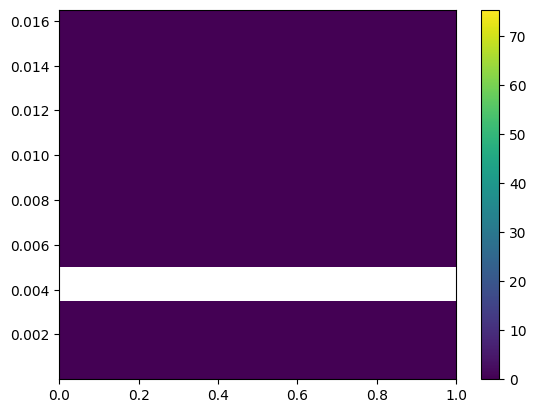

In [38]:
import scipy.sparse.linalg as sla
from matplotlib import pyplot as plt

membrane_reactor = MembraneReactor('test.json')
membrane_reactor.p_R_in = membrane_reactor.p_out
membrane_reactor.p_P_in = membrane_reactor.p_P_out
c = membrane_reactor.c
c_vect = c.ravel()
g, jac = membrane_reactor.construct_g(c, compute_jac=True)
c_vect[:] = sla.spsolve(jac, -g.ravel())
c_P = c[:, 0:membrane_reactor.num_r_P, :]
c_R = c[:, membrane_reactor.num_r_P:, :]


c_max = np.max(c)
print(membrane_reactor.num_timesteps)
plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c, c_R[:, :, 1].T,vmin=0, vmax=c_max)
plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_P, c_P[:, :, 1].T,vmin=0, vmax=c_max)
#plt.pcolormesh(c_P[:, :, 0].T,vmin=0, vmax=1)
plt.colorbar()
plt.show()


#plt.plot(membrane_reactor.r_c_P, c_P[50,:,2],'.')
#plt.plot(membrane_reactor.r_c, c_R[10,:,0],'o')
#plt.plot(membrane_reactor.r_c_P)
#plt.plot(membrane_reactor.r_c)


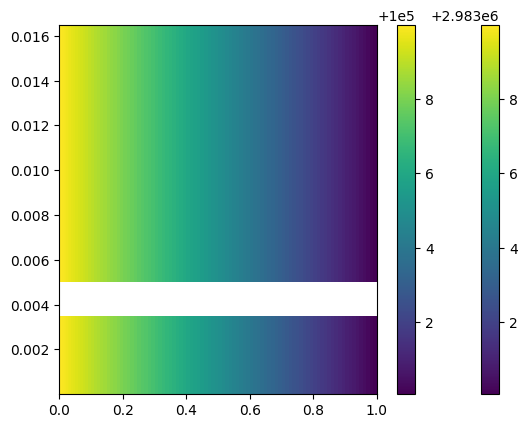

In [18]:
membrane_reactor = MembraneReactor('test.json')

p = membrane_reactor.p
p_vect = p.ravel()
p_P = p[:, :membrane_reactor.num_r_P]
p_R = p[:, membrane_reactor.num_r_P:]

jac_darcy, jac_darcy_bc_P_in, jac_darcy_bc_R_in, g_darcy_bc_out = membrane_reactor.construct_darcy_jacobian()

p_R_in = membrane_reactor.p_out + 10
p_P_in = membrane_reactor.p_P_out + 10
g_p = jac_darcy_bc_P_in*p_P_in + jac_darcy_bc_R_in*p_R_in + g_darcy_bc_out
p_vect[:] = sla.spsolve(jac_darcy, -g_p)
DpDp_R_in = sla.spsolve(jac_darcy, -jac_darcy_bc_R_in)
DpDp_P_in =  sla.spsolve(jac_darcy, -jac_darcy_bc_P_in)

p_min = np.min(p)
p_max = np.max(p)
plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c, p_R[:, :].T)
plt.colorbar()
plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_P, p_P[:, :].T)
#plt.pcolormesh(c_P[:, :, 0].T,vmin=0, vmax=1)
plt.colorbar()
plt.show()

11


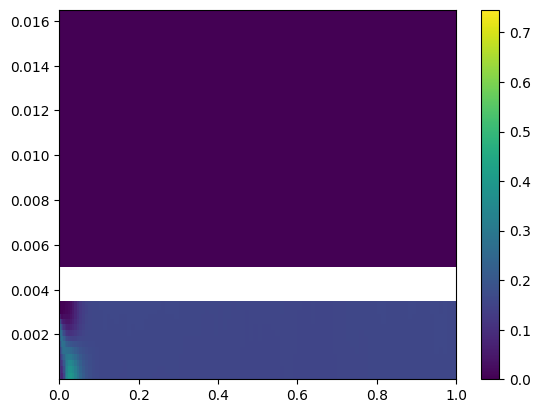

In [ ]:

u_P_ax, u_P_rad, u_R_ax, u_R_rad = membrane_reactor.update_velocity_fields(p, p_P_in, p_R_in) 
g_conv, jac_conv = membrane_reactor.construct_g_conv(compute_jac=True)
g_diff, jac_c_diff = membrane_reactor.construct_g_diff(c, 600, 1e5, compute_jac=True)

g = g_diff + g_conv
jac = jac_c_diff + jac_conv
c_vect[:] = sla.spsolve(jac, -g.ravel())

print(membrane_reactor.num_timesteps)
c_max = np.max(c_vect)
plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c, c_R[:, :, 1].T,vmin=0, vmax=c_max)
plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_P, c_P[:, :, 1].T,vmin=0, vmax=c_max)
#plt.pcolormesh(c_P[:, :, 0].T,vmin=0, vmax=1)
plt.colorbar()
plt.show()


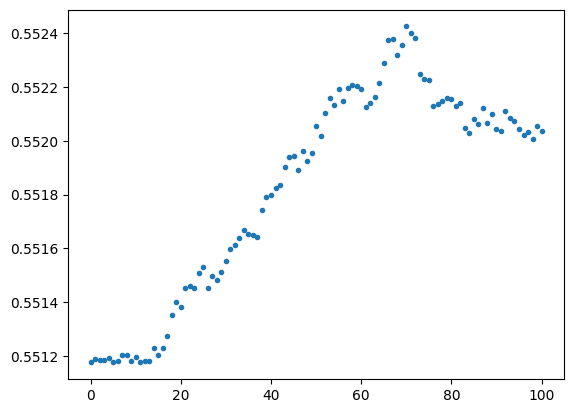

In [25]:
from matplotlib import pyplot as plt

plt.plot(u_P_ax[:,10], '.')
plt.show()

In [ ]:
a = np.ones(10)

NameError: name 'b' is not defined

In [ ]:
for key, value in membrane_reactor.__dict__.items():
    print(f"{key}: {value}")

species: ['H2', 'N2', 'NH3']
database: properties_database.json
dim: 2
num_r: 50
num_z: 100
Rg: 8.31446261815324
T_in: 653.0
T_in_P: 553.0
p_out: 2983000.0
p_out_P: 100000.0
L: 1.0
Lsealing: 0.05
nu: 1
r_min: 0.005
r_max: 0.0165
r_min_P: 0
r_max_P: 0.0035
Perm_NH3: 4e-07
Sel_am_hy: 50.0
Sel_am_ni: 1000.0
Nm: 1
eps: 0.4
Dcat: 0.3333333333333333
rho_c: 590.0
dp: 0.00025
q: 1.5
yNH3_init: 4.4999999999999996e-05
Fmass_NH3_target: 0.14220307029356316
guess_conv: 0.2
SW: 0.05
dt: 0.1
num_timesteps: 11
num_inner_iter: 1
is_restart: True
num_c: 3
rho_b: 117.99999999999999
correlation: <gas_mixture_correlations.GasMixtureCorrelations object at 0x00000168534AA180>
num_r_P: 14
num_r_R: 36
r_f: [0.005      0.00511438 0.00524418 0.00539043 0.00555393 0.00573527
 0.00593475 0.00615237 0.00638784 0.00664057 0.00690977 0.00719441
 0.00749336 0.00780537 0.00812917 0.00846351 0.00880716 0.00915898
 0.00951792 0.009883   0.01025337 0.01062828 0.01100703 0.01138907
 0.01177388 0.01216103 0.01255015 0.0129